In [ ]:
from pricing.heston_option_pricing import train_network as train_network_heston, PINN as PINN_heston
from support_tools.testing_tools import heston_2d_slice_test

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import numpy as np
import matplotlib.pyplot as plt

# Pricing options under Heston model

In [ ]:
# setting up a model
pinn = PINN_heston(
    x_min=np.log(0.01),
    x_max=np.log(15.0),
    v_max=0.5,
    T=4.0,
    r_max=0.2,
    kappa_max=5.0,
    theta_max=0.5,
    sigma_max=0.5,
    call_put="Call",
    hidden=75,
    depth=6
).to(device)

In [ ]:
# either train the model...
history = train_network_heston(
    pinn=pinn,
    N_pde=1000,
    N_boundary=500,
    epochs=7000,
    sigma_mode="mean_reverting",
    lambda_boundary=1.0,
    lambda_terminal=0.5,   
    grad_clip=1.0,
    print_every=100,
    lr=1e-4,               
)

Epoch      1 | Time:       0.12s | LR: 1.000e-04 | Total: 6.712576e+00 | PDE_x: 1.152335e-01 | Terminal_x: 7.732345e-01 | Boundary_x: 6.210726e+00 | GradNorm: 1.413e+02 | Best: 6.712576e+00 @ 1
Epoch    100 | Time:       7.40s | LR: 9.995e-05 | Total: 1.061031e-04 | PDE_x: 4.387788e-05 | Terminal_x: 3.174792e-05 | Boundary_x: 4.635126e-05 | GradNorm: 2.012e-02 | Best: 1.061031e-04 @ 100
Epoch    200 | Time:      14.54s | LR: 9.982e-05 | Total: 6.013044e-05 | PDE_x: 3.062399e-05 | Terminal_x: 1.945147e-05 | Boundary_x: 1.978072e-05 | GradNorm: 1.560e-02 | Best: 5.630075e-05 @ 191
Epoch    300 | Time:      22.05s | LR: 9.959e-05 | Total: 4.178203e-05 | PDE_x: 2.068146e-05 | Terminal_x: 1.515820e-05 | Boundary_x: 1.352146e-05 | GradNorm: 9.771e-03 | Best: 4.178203e-05 @ 300
Epoch    400 | Time:      29.44s | LR: 9.928e-05 | Total: 3.206699e-05 | PDE_x: 1.887380e-05 | Terminal_x: 8.994755e-06 | Boundary_x: 8.695812e-06 | GradNorm: 6.155e-03 | Best: 2.903183e-05 @ 389
Epoch    500 | Time:  

In [4]:
# ...or load the saved ones
state_dict = torch.load('best_pinn_heston_xspace.pt', weights_only=True)['model_state_dict']
pinn.load_state_dict(state_dict)
pinn.eval()

PINN(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=75, bias=True)
    (1): Tanh()
    (2): Linear(in_features=75, out_features=75, bias=True)
    (3): Tanh()
    (4): Linear(in_features=75, out_features=75, bias=True)
    (5): Tanh()
    (6): Linear(in_features=75, out_features=75, bias=True)
    (7): Tanh()
    (8): Linear(in_features=75, out_features=75, bias=True)
    (9): Tanh()
    (10): Linear(in_features=75, out_features=75, bias=True)
    (11): Tanh()
    (12): Linear(in_features=75, out_features=1, bias=True)
  )
)

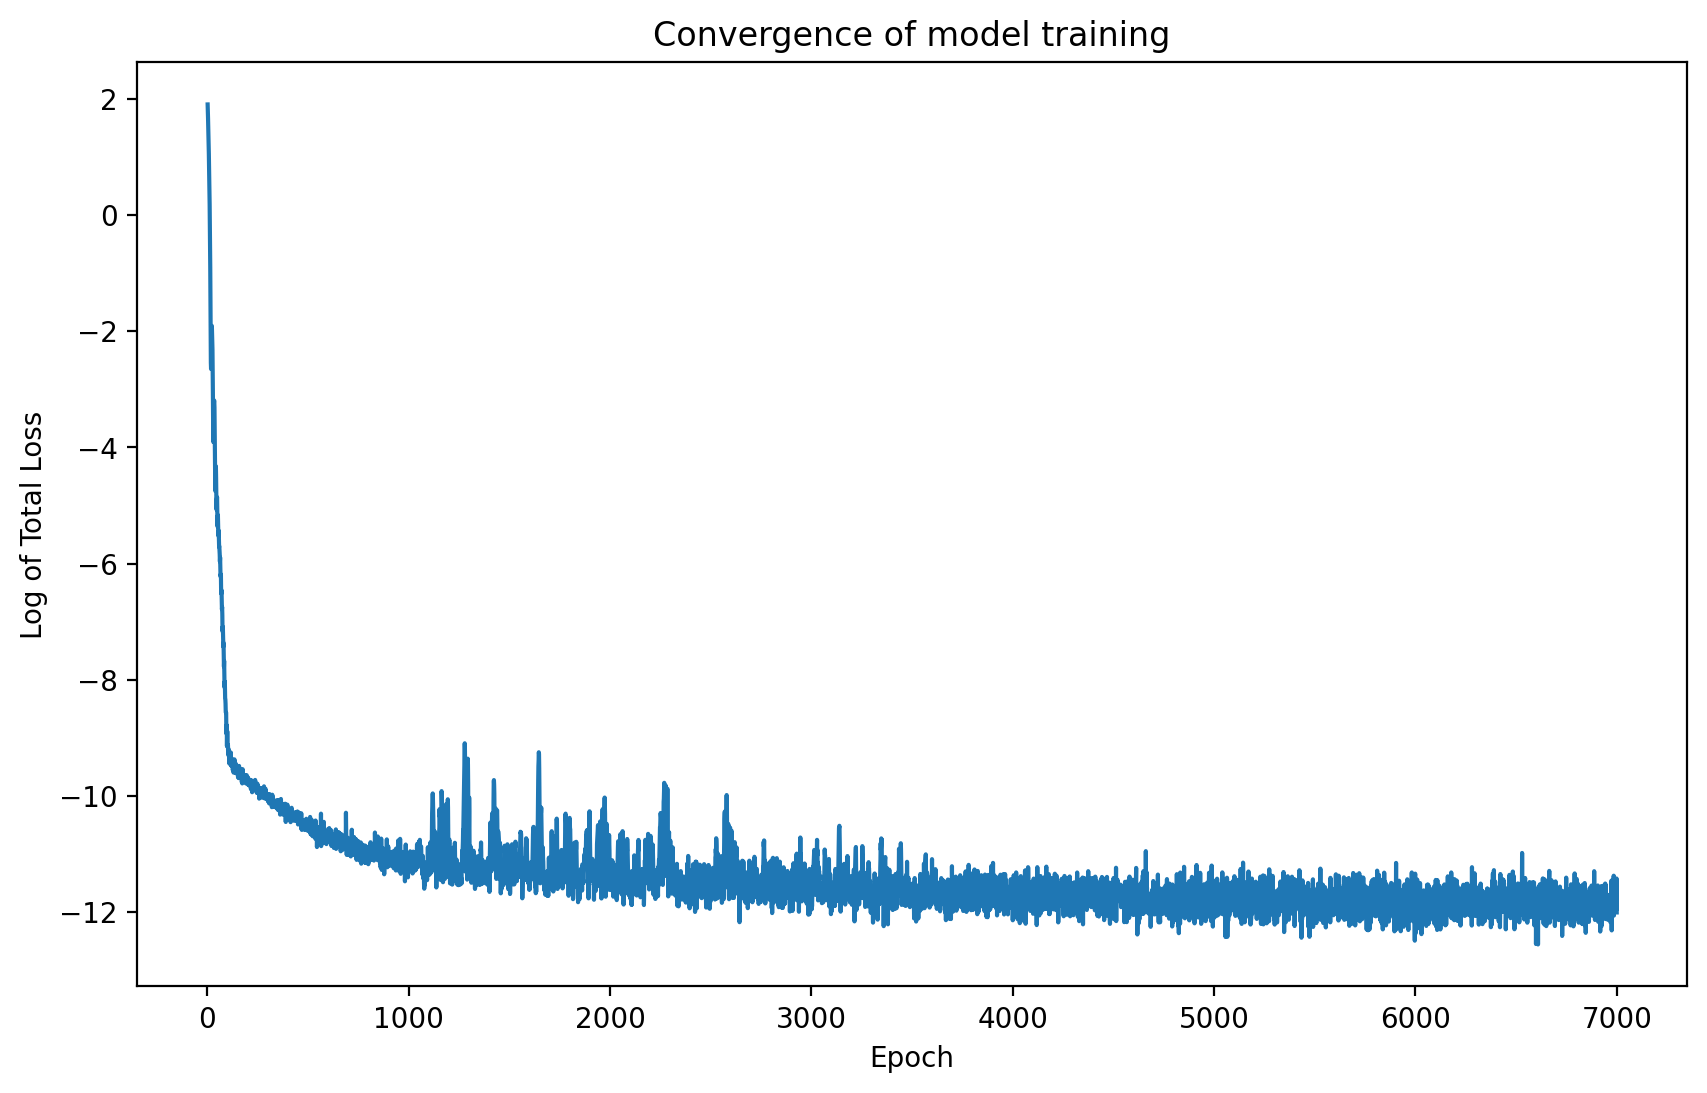

In [21]:
plt.figure(figsize = (10,6), dpi = 200)
plt.plot(history['epoch'], np.log(history["total"]))
plt.xlabel("Epoch")
plt.ylabel("Log of Total Loss")
plt.title("Convergence of model training")
plt.show()

In [5]:
# test the accuracy of the model against quasi-analytical pricing
heston_2d_slice_test(pinn = pinn)

MSE = 0.011344795872346212
RMSE = 0.10651195178169542
MAE = 0.07300287370248465


In [ ]:
N_v     = 3
N_r     = 3
N_sigma = 3
N_kappa = 3
N_theta = 3
N_rho   = 3
N_S     = 3
N_K     = 3          
N_tau   = 3          

# Grids
v_grid     = np.linspace(0.05, 0.5,  N_v)
r_grid     = np.linspace(0.01, 0.2,  N_r)
sigma_grid = np.linspace(0.1,  0.5,  N_sigma)
kappa_grid = np.linspace(0.5,  5.0,  N_kappa)
theta_grid = np.linspace(0.05, 0.5,  N_theta)
rho_grid   = np.linspace(-0.9, 0.9,  N_rho)
S_grid     = np.arange(20, 500, N_S)
K_grid     = np.arange(20, 500, N_K)
tau_grid   = np.linspace(0.01, 4.0, N_tau)

# Full Cartesian grid
V, R, SIG, KAP, TH, RH, S, K, TAU = np.meshgrid(
    v_grid, r_grid, sigma_grid, kappa_grid, theta_grid, rho_grid, S_grid, K_grid, tau_grid,
    indexing='ij'
)

# Flatten
v_flat     = V.ravel()
r_flat     = R.ravel()
sigma_flat = SIG.ravel()
kappa_flat = KAP.ravel()
theta_flat = TH.ravel()
rho_flat   = RH.ravel()
S_flat     = S.ravel()
K_flat =   = K.ravel()
tau_flat   = TAU.ravel()

# Batched PINN prediction
with torch.no_grad():
    pinn_prices = pinn.predict_price(
        S=S_flat,
        v=v_flat,
        tau=tau_flat,
        r=r_flat,
        kappa=kappa_flat,
        theta=theta_flat,
        sigma=sigma_flat,
        rho=rho_flat,
        bs_price_fn=bs_call_torch,
        sigma_mode='mean_reverting'
    )

pinn_prices = np.asarray(pinn_prices).astype(float).reshape(-1)

# Analytical prices: loop only here if scalar-only
anal_prices = np.array([
    heston_call_price(
        spot, K=100, T=tau,
        r=r, q=0.0, v0=v,
        kappa=kappa, theta=theta,
        sigma=sigma, rho=rho
    )
    for spot, K, tau, v, r, sigma, kappa, theta, rho in zip(
        S_flat, K_flattau_flat, v_flat, r_flat, sigma_flat, kappa_flat, theta_flat, rho_flat
    )
], dtype=float)

res = anal_prices - pinn_prices

# Reshape so last axis is tau
res = res.reshape(-1, N_tau)
pinn_prices = pinn_prices.reshape(-1, N_tau)
anal_prices = anal_prices.reshape(-1, N_tau)

print(np.mean(res ** 2))